# EEE 457 Transmissão de Energia Elétrica
## Escola Politécnica
## Universidade Federal do Rio de Janeiro
### Antonio C. S. Lima
Agosto 2025

# Modelo de Linha Média para Linhas de Transmissão Aéreas
Considere um circuito de 230kV com condutor ACSR (Drake), cabos para-raios de 3/8" EHS. 
Os circuitos são baseados em 230CSH1, 230CST1, 230CST3.



In [13]:
# carrega as bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
# configura o matplotlib para usar LaTeX
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 14,
    "font.sans-serif": "Helvetica",
})

In [14]:
# carregando as informações dos parâmetros unitários para cada circuito  
Vbase = 230.0e3
Inominal = 730.0 # de acordo com a informacao sobre os cabos -- condutor Drake 
# circuito 1: 230CSH1 
r11 = 0.0820
x11 = 0.5012
b11 = 3.3180e-6
zc1 = np.sqrt( x11/ b11 )
Pn1 = Vbase**2 / zc1

# circuito 2: 230CST1
r12 = 0.0815
x12 = 0.4402
b12 = 3.7504e-6
zc2 = np.sqrt( x12/ b12 )
Pn2 = Vbase**2 / zc2 

# circuito 3: 230CST3
r13 = 0.0818
x13 = 0.4812
b13 = 3.43760e-6
zc3 = np.sqrt( x13/ b13 )
Pn3 = Vbase**2 / zc3 

In [15]:
# valores das cargas nomrinais arredondados para MW
# cargas nominais Pn1 = 137 MW, Pn2 = 155 MW, Pn3 = 142 MW
pavg = np.sum([Pn1, Pn2, Pn3])/3

print(f'Potência nominal do circuito 1: {Pn1/1e6:.2f} MW')
print(f'Potência nominal do circuito 2: {Pn2/1e6:.2f} MW')
print(f'Potência nominal do circuito 3: {Pn3/1e6:.2f} MW')
print(f'Potência nominal meida entre os 3 circuitos: {pavg/1e6:.2f} MW')

Potência nominal do circuito 1: 136.11 MW
Potência nominal do circuito 2: 154.41 MW
Potência nominal do circuito 3: 141.39 MW
Potência nominal meida entre os 3 circuitos: 143.97 MW


In [16]:
# calculo dos parametros do quadripolo para um circuito de 175km 
compr = 150e3

# para o primeiro circuito
z11 = (r11 + 1j*x11) * compr
y11 = 1j * b11 * compr
A1 = 1 + z11 * y11/2
B1 = z11
C1 = y11 * (1 + z11 * y11/4)
D1 = A1

# para o segundo circuito
z12 = (r12 + 1j*x12) * compr
y12 = 1j * b12 * compr  
A2 = 1 + z12 * y12/2
B2 = z12
C2 = y12 * (1 + z12 * y12/4)
D2 = A2 

# para o terceiro circuito
z13 = (r13 + 1j * x13) * compr
y13 = 1j * b13 * compr  
A3 = 1 + z13 * y13/2
B3 = z13
C3 = y13 * ( 1 + z13 * y13/4)
D3 = A3

In [ ]:
# comparacao das matrizes de quadripolos

In [17]:
# cenarios simulados supondo carga com fator de potencia 0.90 indutivo
theta = np.arccos(0.90)
s = pavg/ .9 * (np.exp(1j * theta ))  # carga total
vr = Vbase/np.sqrt(3)                 # tensao fase-neutro no receptor 
ir = np.conj(s/(3*vr))                # corrente de linha no receptor
print(f'Corrente na carga: {np.abs(ir):.2f} A')
print(f'Angulo da corrente na carga: {np.angle(ir)/np.pi*180:.2f} graus')

Corrente na carga: 401.55 A
Angulo da corrente na carga: -25.84 graus


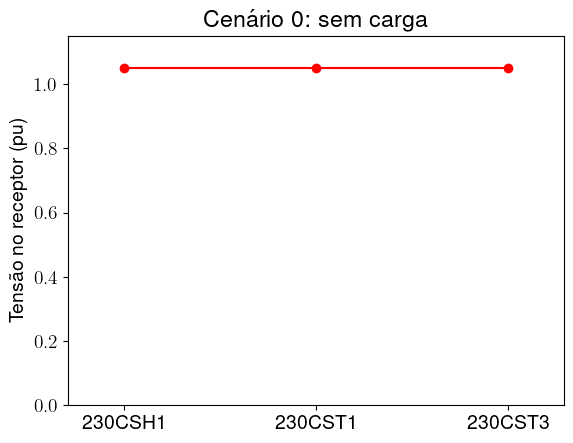

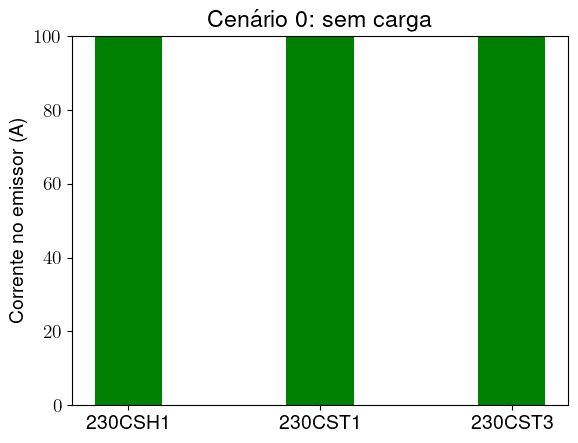

In [19]:
# cenario 0: sem carga (0% da carga nominal)
vr01 = vr / A1
vr02 = vr / A2
vr03 = vr / A3
is01 = C1 * vr 
is02 = C2 * vr 
is03 = C3 * vr
circ = ["230CSH1", "230CST1", "230CST3"]
vvazio = [np.abs(vr01), np.abs(vr02), np.abs(vr03)] / ( Vbase / np.sqrt(3) ) 

plt.bar(circ, vvazio, width=0.35)
vmax = 1.05 * np.array([ 1, 1, 1]) 
plt.plot(circ, vmax, marker='o', color='red', label='Vmax')
plt.ylim(0, 1.15)
plt.ylabel("Tensão no receptor (pu)")
plt.title("Cenário 0: sem carga")
plt.show()

is0 = [np.abs(is01), np.abs(is02), np.abs(is03)]
plt.bar(circ, is0, width=0.35, color='green')

plt.ylim(0, 100)
plt.ylabel("Corrente no emissor (A)")
plt.title("Cenário 0: sem carga")
plt.show()

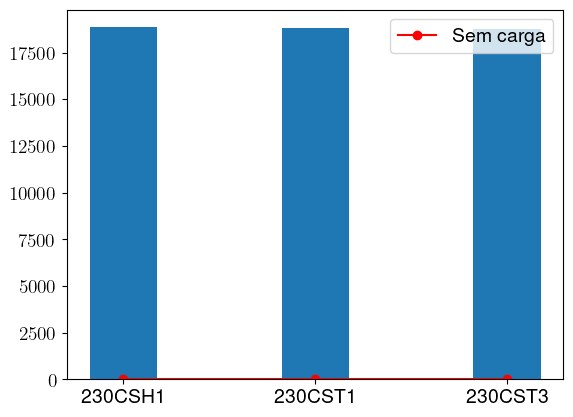

In [ ]:
# cenario 1: carga leve (100% da carga nominal)
vs11 = A1 * vr + B1 * ir
vs12 = A2 * vr + B2 * ir
vs13 = A3 * vr + B3 * ir

is11 = C1 * vr + D1 * ir
is12 = C2 * vr + D2 * ir
is13 = C3 * vr + D3 * ir 

vcen1  = [np.abs(vs11), np.abs(vs12), np.abs(vs13)] / ( Vbase / np.sqrt(3) ) 
plt.bar(circ, vcen1, width=0.35)
plt.plot(circ, vvazio, marker='o', color='red', label='Sem carga')
plt.legend()
plt.show()  

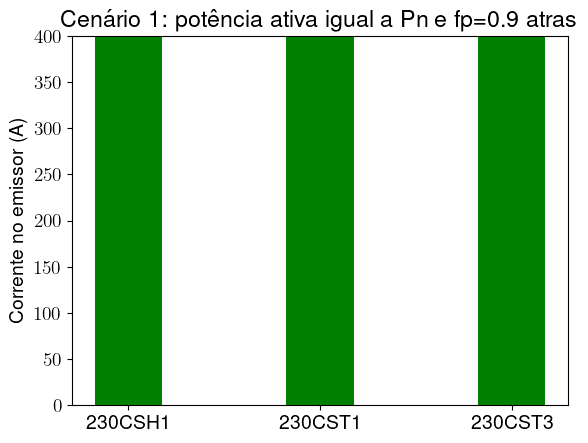

In [ ]:
is1 = [np.abs(is11), np.abs(is12), np.abs(is13)]
plt.bar(circ, is1, width=0.35, color='green')
plt.ylim(0, 400)
plt.ylabel("Corrente no emissor (A)")
plt.title("Cenário 1: potência ativa igual a Pn e fp=0.9 atras")
plt.show()

In [ ]:
# cenario 2: carga nominal (50% da carga nominal com fp=0.9 atras)
s = .5 * pavg/ .9 * (np.exp(1j * theta ))  # carga total
vr = Vbase/np.sqrt(3)                 # tensao fase-neutro no receptor 
ir = np.conj(s/(3*vr))                # corrente de linha no receptor
print(f'Corrente na carga (50%): {np.abs(ir):.2f} A')
print(f'Angulo da corrente na carga: {np.angle(ir)/np.pi*180:.2f} graus')


Corrente na carga (50%): 200.77 A
Angulo da corrente na carga: -25.84 graus


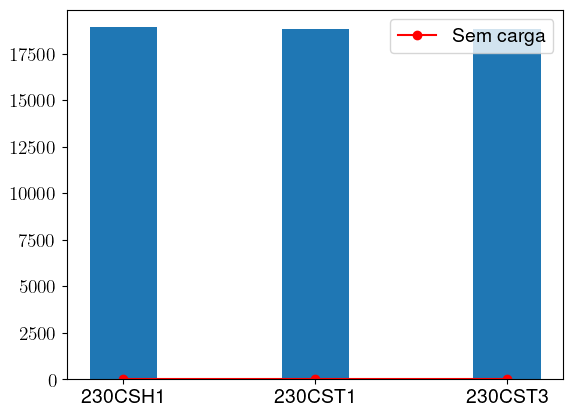

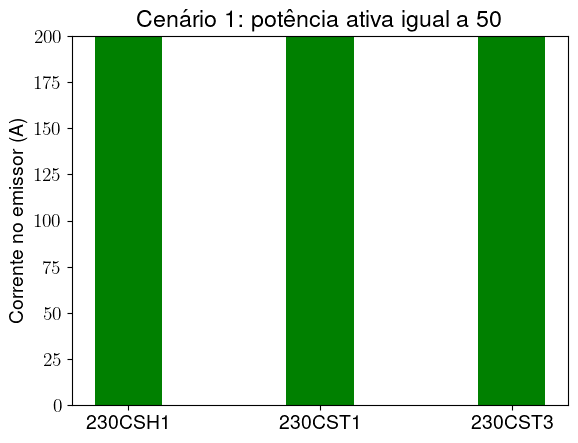

In [ ]:
# cenario 1: carga leve (100% da carga nominal)
vs21 = A1 * vr + B1 * ir
vs22 = A2 * vr + B2 * ir
vs23 = A3 * vr + B3 * ir

is21 = C1 * vr + D1 * ir
is22 = C2 * vr + D2 * ir
is23 = C3 * vr + D3 * ir 

vcen1  = [np.abs(vs21), np.abs(vs22), np.abs(vs23)] / ( Vbase / np.sqrt(3) ) 
plt.bar(circ, vcen1, width=0.35)
plt.plot(circ, vvazio, marker='o', color='red', label='Sem carga')
plt.legend()
plt.show()  
is2 = [np.abs(is21), np.abs(is22), np.abs(is23)]
plt.bar(circ, is2, width=0.35, color='green')
plt.ylim(0, 200)
plt.ylabel("Corrente no emissor (A)")
plt.title("Cenário 1: potência ativa igual a 50% Pn e fp=0.9 atras")
plt.show()

In [ ]:
# cenario 3: carga pesada (200% da carga nominal)